# BASELINES DEL MODEL

## Imports necessaris

In [22]:
import os
import joblib
import warnings
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import BaseEstimator, ClassifierMixin


import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    precision_recall_fscore_support, 
    precision_recall_curve, 
    auc,
    fbeta_score,
    brier_score_loss
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")

### Definicions inicials

In [23]:
DATA_PATH = "../data/processed/dataset_final_pcc.csv"
MODEL_S1_PATH = "../data/processed/model_stage1_v3.joblib"
MODEL_S2_PATH = "../data/processed/model_stage2_v3.joblib"

RANDOM_STATE = 42

print("--- Iniciant entrenament jeràrquic V3 (Ultra Precisió) ---")

if not os.path.exists(DATA_PATH):
    print(f"ERROR: No trobo {DATA_PATH}")
    exit()

df = pd.read_csv(DATA_PATH)

--- Iniciant entrenament jeràrquic V3 (Ultra Precisió) ---


## Preprocessament Comú

In [24]:
drop_cols = ["id_pacient", "target", "cronic"]
X_all = df.drop(columns=[c for c in drop_cols if c in df.columns]).copy()

# Separem les columnes per a processar-les diferent
num_cols = X_all.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_all.select_dtypes(include=["object", "category"]).columns.tolist()

# Preprocessador per tractar les columnes numèriques i categòriques
preprocessor = ColumnTransformer(
    transformers=[
        # Imputem la mediana i escalem les columnes numèriques (mitjana=0, desviació típica=1)
        ("num", Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_cols),
        # Imputem la moda i convertim les columnes categòriques en one-hot
        ("cat", Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
    ]
)


## Mean Baseline

In [25]:
class MeanBaseline(ClassifierMixin, BaseEstimator):
    def __init__(self):
        self.mean_value = None

    def fit(self, X, y):
        """Entrenar: solo calcular la media"""
        self.mean_value = np.mean(y)
        
        # 2. Crea com a mínim un atribut que acabi en '_'
        self.classes_ = np.unique(y)   # Molt recomanable per a classificadors
        self.is_fitted_ = True         # Marca genèrica per a sklearn
        
        return self

    def predict(self, X):
        """Predecir: siempre devolver la media"""
        return np.full(len(X), self.mean_value)

### ESTAT 1: CRÒNIC vs NO

In [26]:
print("\n[Estat 1] Entrenant Chronic vs NO...")

# Mirem si la variable target és major que 0 per a classificar-la com a crònica (1) o no (0).
y1 = (df["target"] > 0).astype(int)
X1_train, X1_test, y1_train, y1_test = train_test_split(X_all, y1, test_size=0.3, random_state=RANDOM_STATE, stratify=y1)

model1 = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", MeanBaseline())
])
model1.fit(X1_train, y1_train)



[Estat 1] Entrenant Chronic vs NO...


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](104,)","['sexe','grup_edat','altres',...,'urea_slope_registrat', 'vit_b12_slope_registrat','vsg_slope_registrat']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,104
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By spe

### ESTAT 2: PCC vs MACA amb CALIBRACIÓ

In [27]:
# =========================================================
print("[Estat 2] Entrenant PCC vs MACA amb HistGradientBoosting + Calibració...")
df_chronic = df[df["target"] > 0].copy()
X2_all = df_chronic.drop(columns=[c for c in drop_cols if c in df_chronic.columns]).copy()
y2 = df_chronic["target"].copy() # 1=PCC, 2=MACA

X2_train, X2_test, y2_train, y2_test = train_test_split(X2_all, y2, test_size=0.3, random_state=RANDOM_STATE, stratify=y2)

model2 = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", MeanBaseline())
])
model2.fit(X2_train, y2_train)


[Estat 2] Entrenant PCC vs MACA amb HistGradientBoosting + Calibració...


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](104,)","['sexe','grup_edat','altres',...,'urea_slope_registrat', 'vit_b12_slope_registrat','vsg_slope_registrat']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,104
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By spe

## 3. AVALUACIÓ ULTRA-PRECIÓ


AVALUACIÓ DETALLADA DEL MODEL JERÀRQUIC

----------------------------------------
1. MÈTRIQUES DETALLADES (INCLOU F2 I BRIER):
----------------------------------------
        Precisió  Recall  F1-Score  F2-Score  PR-AUC  \
Classe                                                 
NO        0.7737     1.0    0.8724    0.9447  0.8869   
PCC       0.0000     0.0    0.0000    0.0000  0.5945   
MACA      0.0000     0.0    0.0000    0.0000  0.5186   

        Brier Score (Calibratge)  Suport  
Classe                                    
NO                        0.4747    8798  
PCC                       0.1587    2149  
MACA                      0.0868     424  

----------------------------------------
2. MITJANES GENERALS (MACRO AVG):
----------------------------------------
Macro avg Precision: 0.2579
Macro avg Recall   : 0.3333
Macro avg F1-Score : 0.2908
Macro avg F2-Score : 0.3149

----------------------------------------
3. MATRIU DE CONFUSIÓ (ABSOLUTA):
------------------------------

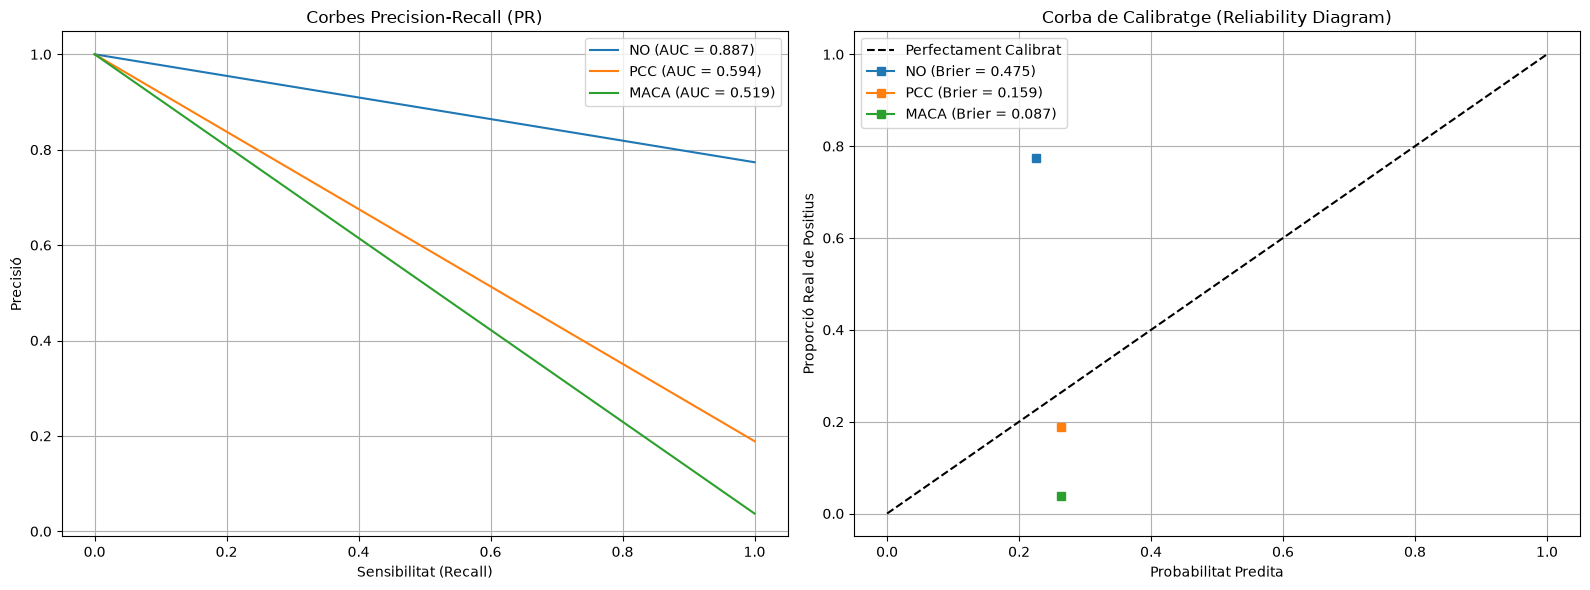

In [33]:
print("\n" + "="*50)
print("AVALUACIÓ DETALLADA DEL MODEL JERÀRQUIC")
print("="*50)

X_final_test, y_final_true = X1_test, df.loc[X1_test.index, "target"]

# 1. Probabilitat de ser crònic (Estat 1)
y1_prob = model1.predict(X_final_test)
y1_pred = (y1_prob >= 0.70).astype(int) 

# 2. Predicció jeràrquica
y_final_pred = np.zeros_like(y1_pred)
chronic_indices = np.where(y1_pred == 1)[0]

if len(chronic_indices) > 0:
    X_chronic_detected = X_final_test.iloc[chronic_indices]
    y2_probs = model2.predict(X_chronic_detected)
    
    # y2_probs[:, 0] -> Prob PCC, y2_probs[:, 1] -> Prob MACA
    THRESHOLD_MACA = 0.40
    y2_pred = np.where(y2_probs[:, 1] >= THRESHOLD_MACA, 2, 1)
    y_final_pred[chronic_indices] = y2_pred

target_names = ["NO", "PCC", "MACA"]

# Càlcul de les probabilitats globals basades en l'estructura jeràrquica:
# P(NO) = P(NO | Stage 1)
# P(PCC) = P(Chronic | Stage 1) * P(PCC | Stage 2)
# P(MACA) = P(Chronic | Stage 1) * P(MACA | Stage 2)
probs_s1 = model1.predict(X_final_test)
p_no = probs_s1
p_chronic = probs_s1

probs_s2 = model2.predict(X_final_test)
p_pcc = p_chronic * probs_s2
p_maca = p_chronic * probs_s2
y_final_probs = np.column_stack([p_no, p_pcc, p_maca])

# Binariitzem les etiquetes reals per a càlculs de corbes
y_final_true_bin = pd.get_dummies(y_final_true).reindex(columns=[0, 1, 2], fill_value=0).values

# Càlculs bàsics (Precision, Recall, F1)
prec, rec, f1, support = precision_recall_fscore_support(y_final_true, y_final_pred, average=None)

# Càlcul de l'F2-Score per a cada classe (dóna el doble d'importància al Recall)
f2_scores = fbeta_score(y_final_true, y_final_pred, beta=2, average=None)

# PR-AUC i Brier Score per a cada classe
pr_aucs = []
brier_scores = []
for i in range(len(target_names)):
    precision_curve, recall_curve, _ = precision_recall_curve(y_final_true_bin[:, i], y_final_probs[:, i])
    pr_aucs.append(auc(recall_curve, precision_curve))
    brier_scores.append(brier_score_loss(y_final_true_bin[:, i], y_final_probs[:, i]))

# =========================================================
# 1. REPORTE GENERAL I TAULA DE MÈTRIQUES PER CLASSE
# =========================================================
print("\n" + "-"*40)
print("1. MÈTRIQUES DETALLADES (INCLOU F2 I BRIER):")
print("-"*40)
metrics_data = {
    "Classe": target_names,
    "Precisió": prec,
    "Recall": rec,
    "F1-Score": f1,
    "F2-Score": f2_scores,
    "PR-AUC": pr_aucs,
    "Brier Score (Calibratge)": brier_scores,
    "Suport": support
}
df_metrics = pd.DataFrame(metrics_data).set_index("Classe")
print(df_metrics.round(4))

# =========================================================
# 2. MITJANES GENERALS (AVGS)
# =========================================================
print("\n" + "-"*40)
print("2. MITJANES GENERALS (MACRO AVG):")
print("-"*40)
macro_f2 = fbeta_score(y_final_true, y_final_pred, beta=2, average='macro')
print(f"Macro avg Precision: {np.mean(prec):.4f}")
print(f"Macro avg Recall   : {np.mean(rec):.4f}")
print(f"Macro avg F1-Score : {np.mean(f1):.4f}")
print(f"Macro avg F2-Score : {macro_f2:.4f}")

# =========================================================
# 3. MATRIUS DE CONFUSIÓ (ABSOLUTA I NORMALITZADA)
# =========================================================
cm = confusion_matrix(y_final_true, y_final_pred)
df_cm = pd.DataFrame(cm, index=target_names, columns=["Pred_NO", "Pred_PCC", "Pred_MACA"])

print("\n" + "-"*40)
print("3. MATRIU DE CONFUSIÓ (ABSOLUTA):")
print("-"*40)
print(df_cm)

# Normalitzada per files (l'element de la diagonal és la sensibilitat/recall de la classe)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
df_cm_norm = pd.DataFrame(cm_norm, index=target_names, columns=["Pred_NO", "Pred_PCC", "Pred_MACA"])
print("\n" + "-"*40)
print("4. MATRIU DE CONFUSIÓ NORMALITZADA (% D'ENCERT REAL / SENSIVILITAT):")
print("-"*40)
print((df_cm_norm * 100).round(2).astype(str) + " %")

# =========================================================
# 4. COMPROVACIÓ D'OBJECTIUS I GUARDAT DE MODELS
# =========================================================
prec_pcc = prec[1]
prec_maca = prec[2]
print(f"\nPRECISIÓ PCC:  {prec_pcc:.4f} " + ("✅ (>80%)" if prec_pcc >= 0.8 else "❌"))
print(f"PRECISIÓ MACA: {prec_maca:.4f} " + ("✅ (>80%)" if prec_maca >= 0.8 else "❌"))

if prec_pcc >= 0.8 and prec_maca >= 0.8:
    joblib.dump(model1, MODEL_S1_PATH)
    joblib.dump(model2, MODEL_S2_PATH)
    print("\nModels super-precisos guardats!")

# =========================================================
# 5. VISUALITZACIONS (CORBES PR I CALIBRATGE)
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# A. Gràfic de les Corbes Precision-Recall (PR)
ax_pr = axes[0]
for i, name in enumerate(target_names):
    precision_curve, recall_curve, _ = precision_recall_curve(y_final_true_bin[:, i], y_final_probs[:, i])
    ax_pr.plot(recall_curve, precision_curve, label=f"{name} (AUC = {pr_aucs[i]:.3f})")
ax_pr.set_title("Corbes Precision-Recall (PR)")
ax_pr.set_xlabel("Sensibilitat (Recall)")
ax_pr.set_ylabel("Precisió")
ax_pr.legend()
ax_pr.grid(True)

# B. Gràfic de la Corba de Calibratge (Calibration Curve)
ax_cal = axes[1]
ax_cal.plot([0, 1], [0, 1], "k--", label="Perfectament Calibrat")
for i, name in enumerate(target_names):
    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_final_true_bin[:, i], y_final_probs[:, i], n_bins=10, strategy='uniform'
    )
    ax_cal.plot(mean_predicted_value, fraction_of_positives, "s-", label=f"{name} (Brier = {brier_scores[i]:.3f})")
ax_cal.set_title("Corba de Calibratge (Reliability Diagram)")
ax_cal.set_xlabel("Probabilitat Predita")
ax_cal.set_ylabel("Proporció Real de Positius")
ax_cal.legend()
ax_cal.grid(True)

plt.tight_layout()
plt.show()
